## Lab 4: Generating CDFs

**Names:** Hannah Sweazey, Hannah Dykens, Tejas Reddy, Susanna Huang

In [2]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
def ecdf_xy(samples):
    x = np.sort(np.asarray(samples))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


def plot_ecdf_vs_cdf(samples, cdf, grid=None, title="", xlabel="", discrete=False, logx=False):
    x, y = ecdf_xy(samples)
    fig, ax = plt.subplots()
    ax.step(x, y, where="post", lw=2, label="simulation ECDF")

    if grid is None:
        lo, hi = np.quantile(x, [0.001, 0.999])
        grid = np.linspace(lo, hi, 400)
    if discrete:
        ax.step(grid, cdf(grid), where="post", lw=2, label="scipy CDF")
    else:
        ax.plot(grid, cdf(grid), lw=2, label="scipy CDF")

    if logx:
        ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("cumulative probability")
    ax.legend()
    return ax


def show_quantiles(samples, dist, probs=(0.1, 0.25, 0.5, 0.75, 0.9)):
    return pd.DataFrame({
        "p": probs,
        "simulation": np.quantile(samples, probs),
        "scipy": dist.ppf(probs),
    })

## Q1

In [4]:
K = 5
grid = np.linspace(0, 1, K)
random_value_from_grid = np.random.choice(grid)
random_value_from_grid

np.float64(0.25)

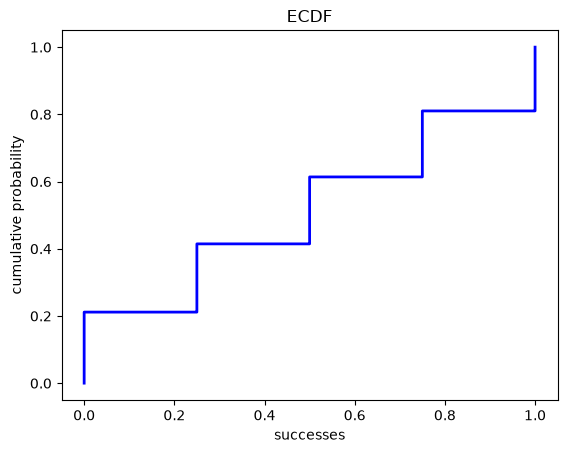

In [5]:
#ECDF with n = 5000 and K = 1
N = K
pA = np.ones(K) /K
rng = np.random.default_rng()
sampleA = rng.choice(a = grid, size = 5000, p = pA)

#left plot: ECDF plot
x, y = ecdf_xy(sampleA)  
plt.step(x, y, where='post', color='blue', lw=2, label=f"p = {pA}, sample proportion = {sampleA.mean():.3f}")
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

In [6]:
K = 100
grid = np.linspace(0, 1, K)
random_value_from_grid = np.random.choice(grid)
random_value_from_grid

np.float64(0.29292929292929293)

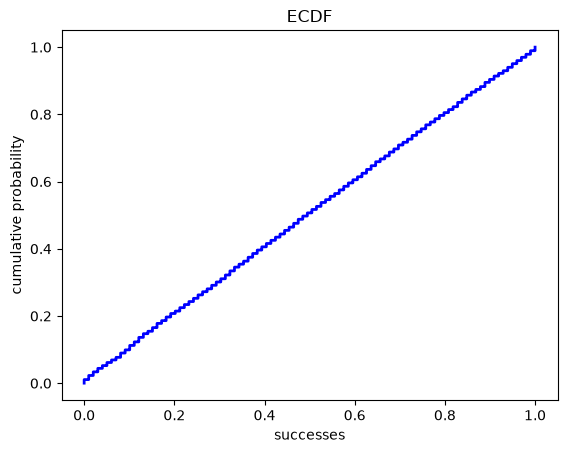

In [7]:
#ECDF with n = 5000 and K = 100
N = K
pA = np.ones(K) /K
rng = np.random.default_rng()
sampleA = rng.choice(a = grid, size = 5000, p = pA)

#left plot: ECDF plot
x, y = ecdf_xy(sampleA)  
plt.step(x, y, where='post', color='blue', lw=2, label=f"p = {pA}, sample proportion = {sampleA.mean():.3f}")
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

In [8]:
K = 10000
grid = np.linspace(0, 1, K)
random_value_from_grid = np.random.choice(grid)
random_value_from_grid

np.float64(0.26362636263626366)

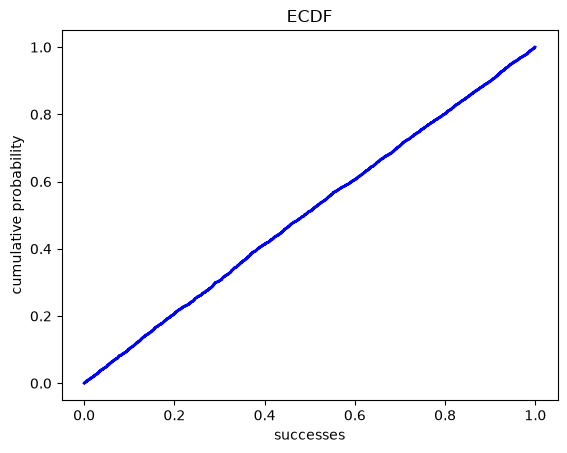

In [9]:
#ECDF with n = 5000 and K = 10,000
N = K
pA = np.ones(K) /K
rng = np.random.default_rng()
sampleA = rng.choice(a = grid, size = 5000, p = pA)

#left plot: ECDF plot
x, y = ecdf_xy(sampleA)  
plt.step(x, y, where='post', color='blue', lw=2, label=f"p = {pA}, sample proportion = {sampleA.mean():.3f}")
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

### 4.
As you increase $K$, the distribution approaches a uniform distribution.

## Q2.


In [11]:
# Using RNG, build a sample with p = 0.1 and a second sample with p = 0.105, each with N = 200. 
N = 32

sampleA = rng.uniform((np.sqrt(3)* -1), np.sqrt(3), size= N)

trial_pathsA = sampleA.mean() #summing along the trial axis to get cumulative successes
# Make a plot of the running trials and compare.

print(sampleA)
print(trial_pathsA)

[ 1.70327527 -1.70552782  1.59427982 -1.13366827 -0.55724937 -0.85245831
  0.41109266  1.25876693  1.32856601 -0.62898528  0.87105014 -0.53536748
 -0.22987361  0.29421269 -1.64405813  1.04028442  0.3982365  -1.59835314
 -1.1627961  -0.19874996 -0.48168193 -0.33969893 -1.34245406  0.30718647
  1.44421924  1.65013326  0.03836922  0.87164923 -1.12430162 -1.40597421
 -1.34533262  0.70968817]
-0.07392252448076062


In [ ]:
trial_pathsA * np.sqrt(N)

np.float64(-0.41816894674219524)

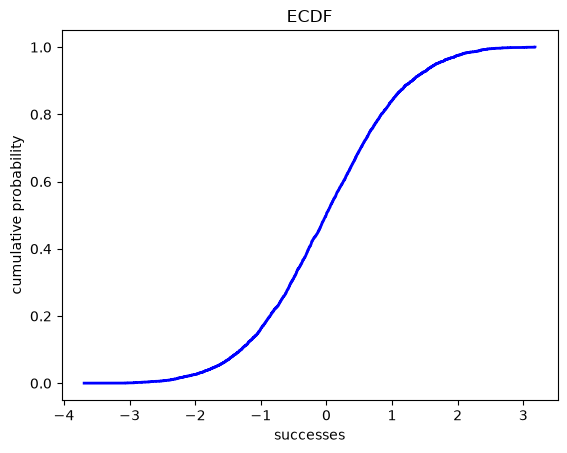

In [16]:
rng = np.random.default_rng()
sampleA = rng.uniform((np.sqrt(3)* -1), np.sqrt(3), size = [5000,32])

mean_of_everything = np.mean(sampleA, axis=1) * np.sqrt(N)

#left plot: ECDF plot
x, y = ecdf_xy(mean_of_everything)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

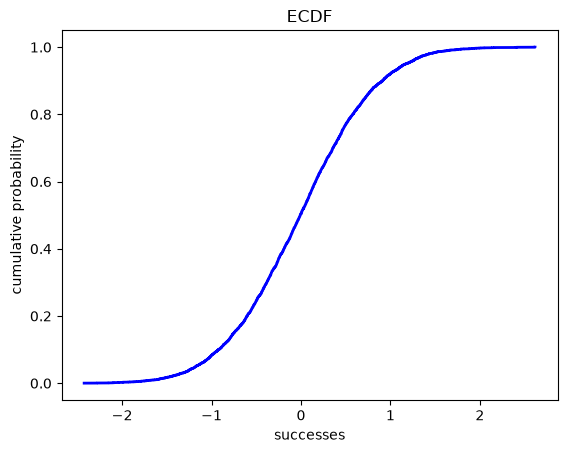

In [17]:
rng = np.random.default_rng()
sampleA = rng.uniform((np.sqrt(3)* -1), np.sqrt(3), size = [5000,64])

mean_of_everything = np.mean(sampleA, axis=1) * np.sqrt(N)

#left plot: ECDF plot
x, y = ecdf_xy(mean_of_everything)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

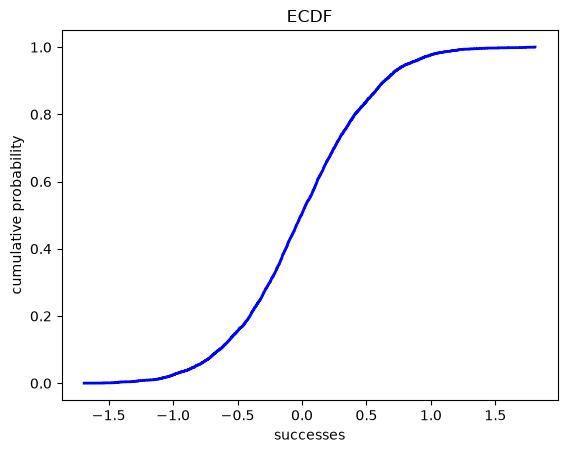

In [18]:
rng = np.random.default_rng()
sampleA = rng.uniform((np.sqrt(3)* -1), np.sqrt(3), size = [5000,128])

mean_of_everything = np.mean(sampleA, axis=1) * np.sqrt(N)

#left plot: ECDF plot
x, y = ecdf_xy(mean_of_everything)  
plt.step(x, y, where='post', color='blue', lw=2)
plt.title("ECDF")
plt.xlabel("successes")
plt.ylabel("cumulative probability")
plt.show()

### 4.

As n increases, this more closely approaches a normal distribution and the x axis range condenses.

## Q3

AI Statement: We used ChatGPT to help us understand our "TypeError: object of type 'float' has no len()" error when using np.random.default_rng().choice().